# Ligand-Receptor Interaction Correlation (LRIC) - Multi-sample


This notebook extends the cross-PCF and LRIC workflows introduced [in this tutorial](https://github.com/AtheerAS/liana-py/blob/fix/LRIC-analytical/docs/notebooks/LRIC_tutorial.ipynb) to multi-sample spatial analysis. Rather than analysing a single tissue section, the methods are applied across multiple samples to evaluate the consistency and variability of spatial cell-type organisation and ligand–receptor enrichment between sections.

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from itertools import islice
import copy
from scipy import sparse
import os

import liana as li

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

We use Xenium 5K spatial transcriptomics samples from [McGregor et al., 2025, *Spatial fibroblast niches define Crohn's fistulae*, Nature](https://doi.org/10.1038/s41586-025-09744-y), a subcellular-resolution spatial atlas of intestinal fistulae in Crohn's disease. Samples are annotated by tissue `TYPE` (healthy control, ulcer, fistula) and `LOCATION` (colon, ileum), with cell types provided under `CellAnnotation.Level0`.

The helper below loads one sample: it keeps annotated cells, filters low-count cells/genes, stores raw counts, normalises and log-transforms expression, and subsets to highly variable genes.

In [2]:
def load_crohn_slide(
    sample_id: str,
    data_dir: str = "/g/stegle/aalsayah/repos/data/xenium5k/agne_cd",
    n_top_genes: int = 3000,
    labels_key: str = "CellAnnotation.Level0",
):
    adata = sc.read_h5ad(Path(data_dir) / f"{sample_id}.h5ad")
    adata.obs_names_make_unique()
    # Keep cells with available annotations.
    adata = adata[adata.obs[labels_key].notna()].copy()

    sc.pp.filter_cells(adata, min_counts=3)
    sc.pp.filter_genes(adata, min_counts=3)

    adata.obs[labels_key] = adata.obs[labels_key].astype("category")
    adata.obsm["spatial"] = adata.obs[["x", "y"]].values

    # Preserve raw counts before normalization and log transformation.
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    sc.pp.highly_variable_genes(
        adata,
        layer="counts",
        flavor="seurat_v3",
        n_top_genes=min(n_top_genes, adata.n_vars),
        subset=True,
    )
    return adata

In [3]:
sample_ids = ["RUN1_SLIDE1_S3", "RUN1_SLIDE2_S7", "RUN2_SLIDE1_S5", "RUN3_SLIDE1_S4", "RUN3_SLIDE1_S7", "RUN3_SLIDE1_S5"]  # 3 HC vs. 3 FISTULA
data_dir = "/g/stegle/aalsayah/repos/data/xenium5k/agne_cd"

adata_list = [load_crohn_slide(sample_id=sid, data_dir=data_dir) for sid in sample_ids]

## Ligand–Receptor Database

In [4]:
resource = li.rs.select_resource('consensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

4624 LR pairs in resource


,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


In [5]:
### set variables
spatial_key = "spatial"
cell_type_key = "CellAnnotation.Level0"
annulus_width = 20
radius_step = 20

## Run cross PCF and LRIC

In [6]:
for ad in adata_list:
    li.mt.cross_pcf(ad, 
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            key_added="cross_pcf")

    li.mt.lric(
            ad,
            resource=resource,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            expr_prop=0.02,  # NaN-mask ligand/receptor pairs expressed in <2% of cells
            use_raw=False,
            key_added="lric_ag",  #results will be saved under this label in adata.uns
            verbose=True,
        )

    li.mt.lric(
            ad,
            resource=resource,
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            expr_prop=0.02,  # NaN-mask sender/receiver-celltype pairs expressed in <2% of that celltype
            use_raw=False,
            key_added="lric_ct", #results will be saved under this label in adata.uns
            verbose=True,
        )

Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.
`min_cells=None`: dropping cell types with <= 1.0% of 103899 cells (min_cells=1039).
Using `.X`!
The following cell identities were excluded: B-Cells, Lymphatics, Neurons, Neutrophils


Using provided `resource`.


Running LRIC (conditional within-type null) for 11 cell types (110 directed pairs).
LRIC: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [02:37<00:00,  1.43s/it]
Using `.X`!


...

Running LRIC (conditional within-type null) for 12 cell types (132 directed pairs).
LRIC: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [00:50<00:00,  2.62it/s]
Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.
`min_cells=None`: dropping cell types with <= 1.0% of 81825 cells (min_cells=819).
Using `.X`!
The following cell identities were excluded: Neurons


Using provided `resource`.


Running LRIC (conditional within-type null) for 14 cell types (182 directed pairs).
LRIC: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [01:30<00:00,  2.00it/s]


In [34]:
HALF_ANNULUS = annulus_width / 2         # inner-edge radius -> annulus centre
G_FLOOR      = 0.05                      # floor on g(r) before log2 (keeps empty/depleted bins finite)

def _log2g(curve):
    """log2 g(r), g floored at G_FLOOR to keep empty/depleted bins finite."""
    return np.log2(np.maximum(np.asarray(curve, float), G_FLOOR))
def _iter_features(adata, modality):
    """Yield (feature_key, g(r) profile) for every feature in adata.uns[modality]."""
    d = adata.uns[modality]; r = np.asarray(d["radii"], float)
    if modality == "cross_pcf":                       # symmetric: emit each unordered pair once
        seen = set()
        for k, c in d["results"].items():
            if frozenset(k) not in seen and not seen.add(frozenset(k)):
                yield k, np.asarray(c, float).ravel()
    elif modality == "lric_ag":
        M = np.asarray(d["lric"], float); M = M if M.shape[0] == r.size else M.T
        for j, lr in enumerate(d["pair_names"]): yield lr, M[:, j]
    elif modality == "lric_ct":
        for k, a in d["results"].items():
            A = np.asarray(a, float); A = A if A.shape[0] == r.size else A.T
            for j, lr in enumerate(d["pair_names"]): yield (k, lr), A[:, j]
    else:
        raise ValueError(f"unknown modality {modality!r}")

def _feature_label(feat, modality):
    if modality == "cross_pcf": return f"{feat[0]} ↔ {feat[1]}"
    if modality == "lric_ag":   return feat.replace("^", " → ")
    (a, b), lr = feat;          return f"{a} → {b}\n{lr.replace('^', ' → ')}"

def auc_log2_score(adata, modality, max_dist=None, normalize=True, min_bins=3):
    """(Mean) area under log2 g(r) — one signed score per interaction.

    >0 co-enriched, <0 depleted, 0 = random. `modality` is one of
    "cross_pcf"/"lric_ag"/"lric_ct" or any iterable of them; multiple ->
    one long frame with a `modality` column.

    max_dist  : integrate only over r < max_dist (radius units); None -> all r.
    normalize : True  -> integral / radial span = mean log2 FC (comparable across samples);
                False -> raw integral (log2 * radius units; single-sample).
    min_bins  : drop pairs with < this many finite log2 g(r) in the window
                (support gate; catches expr_prop-masked & degenerate pairs).
    """
    mods = [modality] if isinstance(modality, str) else list(modality)
    rows = []
    for mod in mods:
        radii = np.asarray(adata.uns[mod]["radii"], float)
        x_all = radii + HALF_ANNULUS
        win = radii < max_dist if max_dist is not None else np.ones(radii.size, bool)
        for key, curve in _iter_features(adata, mod):
            y = _log2g(np.asarray(curve, float))
            m = win & np.isfinite(y) & np.isfinite(x_all)
            if m.sum() < min_bins:                       # support gate
                continue
            x, yv = x_all[m], y[m]
            span = x.max() - x.min()
            area = np.trapezoid(yv, x)
            rows.append({
                "modality": mod,
                "feature": key,
                "label": _feature_label(key, mod).replace("\n", "  "),
                "score": area / span if (normalize and span > 0) else area,
            })
    cols = ["modality", "feature", "label", "score"]
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows, columns=cols).sort_values("score", ascending=False, ignore_index=True)

In [35]:
from matplotlib.colors import LinearSegmentedColormap, to_rgb

C_TOP, C_BOT, C_REST = "#009E73", "#D55E00", "#BBBBBB"

def _clean(ax):
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
def _grey(ax, xy, s): ax.scatter(*xy.T, s=s * .35, c="#E9E9E9", linewidths=0, rasterized=True)
def _seq_cmap(base):
    """Clean single-hue light→dark ramp: low expr = light tint (hue kept, distinct from the
    grey background), high expr = dark and pops."""
    c = np.array(to_rgb(base)); lo = 1 - 0.25 * (1 - c)
    return LinearSegmentedColormap.from_list("seq", [lo, c, 0.5 * c])

def _gene_vals(adata, name, layer=None, complex_sep="_"):
    """1-D expression for a gene, or the min-subunit value of a complex."""
    cols = [name] if name in adata.var_names else [g for g in name.split(complex_sep) if g in adata.var_names]
    if not cols: raise KeyError(f"{name!r} not in adata.var_names")
    X = adata[:, cols].layers[layer] if layer else adata[:, cols].X
    X = X.toarray() if sparse.issparse(X) else np.asarray(X)
    return X.min(1).ravel()

def _panel_types(ax, coords, types, a, b, s):
    _grey(ax, coords[~np.isin(types, (a, b))], s)
    for ct, col in ((a, C_TOP), (b, C_BOT)):
        m = types == ct
        ax.scatter(*coords[m].T, s=s, c=col, linewidths=0, label=f"{ct}  (n={int(m.sum())})", rasterized=True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), fontsize=8,
              markerscale=2, frameon=False); _clean(ax)

def _panel_expr(ax, coords, vals, title, cmap, s, focus=None, clip=(2, 98), floor=0.0):
    keep = np.ones(len(vals), bool) if focus is None else np.asarray(focus)
    expr = keep & (vals > floor)                            # only real expressers get colour;
    _grey(ax, coords[~expr], s)                             # non-expressing (<=floor) + off-type = grey
    cx, cv = coords[expr], vals[expr]
    if cv.size:
        lo, hi = np.nanpercentile(cv, clip)                 # contrast spans the expressers, not the zeros
        o = np.argsort(cv)                                  # high-expressing cells on top
        sc = ax.scatter(*cx[o].T, c=cv[o], s=s * 1.3, cmap=cmap, vmin=lo, vmax=max(hi, lo + 1e-9),
                        linewidths=0, rasterized=True)
        cb = ax.figure.colorbar(sc, ax=ax, shrink=.55, aspect=28, pad=.01)
        cb.outline.set_visible(False); cb.ax.tick_params(labelsize=7, length=2)
    ax.set_title(title, fontsize=11); _clean(ax)

def plot_interaction(adata, modality, feature, *, groupby=None, spatial_key="spatial", lr_sep="^",
                     layer=None, complex_sep="_", max_dist=None, cmap=None, s=6, expr_floor=0.0, figsize=None):
    """g(r) curve(s) + spatial context for one interaction. cross_pcf: 1 cell-type panel;
    lric_ag: 2 expression panels; lric_ct: 3 curves (full/g_pcf/g_expr) + cell-type panel +
    ligand/receptor expression masked to sender/receiver cells."""
    d = adata.uns[modality]; radii = np.asarray(d["radii"], float)
    coords = np.asarray(adata.obsm[spatial_key], float)
    title = _feature_label(feature, modality).replace("\n", "  ")
    if modality == "cross_pcf":
        curves = {"g(r)": np.asarray(d["results"][feature], float)}; spatial = [("types", feature)]
    elif modality == "lric_ag":
        M = np.asarray(d["lric"], float); M = M if M.shape[0] == radii.size else M.T
        curves = {"g(r)": M[:, d["pair_names"].index(feature)]}
        lig, rec = feature.split(lr_sep)
        spatial = [("expr", (lig, None, C_TOP)), ("expr", (rec, None, C_BOT))]
    elif modality == "lric_ct":
        (s_, r_), lr = feature; j = d["pair_names"].index(lr)
        def col(k): a = np.asarray(d[k][(s_, r_)], float); return a[:, j] if a.ndim == 2 else a
        curves = {"g (full)": col("results"), "g_pcf": col("g_pcf"), "g_expr": col("g_expr")}
        spatial = [("types", (s_, r_))] + [("expr", (g, ct, cl)) for g, ct, cl in
                   zip(lr.split(lr_sep), (s_, r_), (C_TOP, C_BOT))]
    else:
        raise ValueError(f"unknown modality {modality!r}")

    fig, axes = plt.subplots(1, 1 + len(spatial), figsize=figsize or (5 * (1 + len(spatial)), 4.0))
    axes = np.atleast_1d(axes); ax = axes[0]
    for lbl, y in curves.items(): ax.plot(radii, y, marker="o", ms=3, lw=1.5, label=lbl)
    ax.axhline(1, color="k", ls="--", lw=1)
    if max_dist is not None: ax.axvspan(radii.min(), max_dist, color="0.92", zorder=0)
    ax.set_xlabel("r"); ax.set_ylabel("g(r)"); ax.set_title(title)
    if len(curves) > 1: ax.legend(fontsize=8)

    types = adata.obs[groupby].astype(str).values if groupby is not None else None
    for ax, (kind, arg) in zip(axes[1:], spatial):
        if kind == "types":
            if types is None: raise ValueError("groupby is required for cell-type spatial panels")
            _panel_types(ax, coords, types, *arg, s)
        else:
            gene, ct, base = arg
            pc = cmap if cmap is not None else _seq_cmap(base)
            _panel_expr(ax, coords, _gene_vals(adata, gene, layer, complex_sep), gene, pc, s,
                        None if ct is None else types == ct, floor=expr_floor)
    fig.tight_layout(); return fig

def _ranked_or_raise(adata, modality, max_dist, normalize, min_bins):
    """auc_log2_score, but raise an actionable error instead of returning nothing to plot."""
    df = auc_log2_score(adata, modality, max_dist=max_dist, normalize=normalize, min_bins=min_bins)
    if len(df): return df
    radii = np.asarray(adata.uns[modality]["radii"], float)
    nwin = int((radii < max_dist).sum()) if max_dist is not None else radii.size
    why = (f"only {nwin} radius bin(s) lie within max_dist={max_dist}, below min_bins={min_bins} — "
           f"set min_bins<={nwin}, raise max_dist, or recompute with a finer radius_step"
           if nwin < min_bins else
           f"every interaction has <{min_bins} finite g(r) bins in-window "
           f"(expr_prop masking / sparse geometry) — lower min_bins or expr_prop")
    raise ValueError(f"No interactions to plot for {modality!r}: {why}.")

def plot_top_heatmap(adata, modality, *, n=5, max_dist=None, normalize=True, min_bins=3,
                     direction="enrich", cmap="RdBu_r", figsize=None):
    """Top-N interactions as an interaction × radius heatmap of log2 g(r); rows ranked/
    selected by auc_log2_score. direction: 'enrich' | 'deplete' | 'both'."""
    df = _ranked_or_raise(adata, modality, max_dist, normalize, min_bins)
    sel = {"enrich": df.head(n), "deplete": df.tail(n)[::-1],
           "both": pd.concat([df.head(n), df.tail(n)[::-1]]).drop_duplicates("feature")}[direction]
    radii = np.asarray(adata.uns[modality]["radii"], float)
    curves = dict(_iter_features(adata, modality))
    M = np.vstack([_log2g(np.asarray(curves[f], float)) for f in sel["feature"]])
    lim = np.nanmax(np.abs(M)) or 1.0
    cmap = copy.copy(plt.get_cmap(cmap)); cmap.set_bad("0.85")           # NaN bins → grey
    fig, ax = plt.subplots(figsize=figsize or (0.45 * radii.size + 3, 0.5 * len(sel) + 1.5))
    im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=-lim, vmax=lim)
    ax.set_xticks(range(radii.size)); ax.set_xticklabels([f"{r:g}" for r in radii], fontsize=7)
    ax.set_yticks(range(len(sel))); ax.set_yticklabels(sel["label"], fontsize=8); ax.set_xlabel("r")
    if max_dist is not None: ax.axvline(np.searchsorted(radii, max_dist) - 0.5, color="k", ls=":", lw=1)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="log2 g(r)")
    fig.tight_layout(); return fig

def _callouts(ax, xs, ys, labels, color, top):
    """Leader-line labels to a handful of points, stacked in an empty corner (top-right for
    the leaders, bottom-left for the trailers) so text never overlaps the cloud."""
    tys = np.linspace(.99, .84, len(labels)) if top else np.linspace(.16, .01, len(labels))
    for x, y, lab, ty in zip(xs, ys, labels, tys):
        ax.annotate(lab, (x, y), xytext=(.46 if top else .0, ty), textcoords="axes fraction",
                    fontsize=7, ha="left", va="center", color=color,
                    arrowprops=dict(arrowstyle="-", lw=.5, color=color, alpha=.6))

def plot_landscape(adata, modality, *, max_dist=None, normalize=True, min_bins=3, top=3, figsize=None):
    """auc_log2 score vs rank for every interaction (all modalities). The bulk is grey; the
    top & bottom `top` are highlighted and called out with leader lines."""
    df = _ranked_or_raise(adata, modality, max_dist, normalize, min_bins)
    y = df["score"].to_numpy(); x = np.arange(len(y)); lab = df["label"].to_numpy()
    k = min(top, len(df) // 2)
    fig, ax = plt.subplots(figsize=figsize or (8.5, 5))
    ax.scatter(x, y, s=8, c="0.55", linewidths=0, zorder=2)
    ax.axhline(0, color="k", lw=.7, ls="--", zorder=1)
    for i, color, is_top in ((x[:k], C_TOP, True), (x[len(x) - k:], C_BOT, False)):
        ax.scatter(i, y[i], s=42, c=color, linewidths=0, zorder=3)
        _callouts(ax, i, y[i], lab[i], color, is_top)
    ax.set_xlabel("rank (most → least enriched)"); ax.set_ylabel("auc_log2 score")
    ax.set_title(f"{modality} : {len(y)} interactions")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    fig.tight_layout(); return fig

In [36]:
def auc_across_samples(adata_list, modality, *, sample_key=None, group_key=None, **kw):
    """auc_log2_score on every sample, stacked into one tidy long frame for cross-sample
    boxplots. modality: one name or an iterable (stacked w/ a `modality` column).
    sample_key/group_key: obs columns (constant per sample). **kw -> auc_log2_score."""
    out = []
    for i, ad in enumerate(adata_list):
        df = auc_log2_score(ad, modality, **kw)
        df.insert(0, "sample", str(ad.obs[sample_key].iloc[0]) if sample_key else f"S{i}")
        if group_key: df.insert(1, "group", str(ad.obs[group_key].iloc[0]))
        out.append(df)
    return pd.concat(out, ignore_index=True)

In [37]:
auc_df = auc_across_samples(
    adata_list, ("cross_pcf", "lric_ag", "lric_ct"),
    sample_key="SAMPLE", group_key="TYPE", max_dist=100)   # normalize=True (default)


In [38]:
auc_df

,sample,group,modality,feature,label,score
0,RUN1_SLIDE1_S3,HC,lric_ct,"((T-Cells, DCs), C3^ITGAX)",T-Cells → DCs C3 → ITGAX,2.308329
1,RUN1_SLIDE1_S3,HC,lric_ct,"((T-Cells, DCs), C3^ITGAM)",T-Cells → DCs C3 → ITGAM,1.999460
2,RUN1_SLIDE1_S3,HC,lric_ct,"((DCs, T-Cells), MMP9^CD44)",DCs → T-Cells MMP9 → CD44,1.952969
3,RUN1_SLIDE1_S3,HC,lric_ct,"((DCs, T-Cells), MMP9^IFNAR1)",DCs → T-Cells MMP9 → IFNAR1,1.856340
4,RUN1_SLIDE1_S3,HC,lric_ct,"((Macrophages, DCs), CXCL9^DPP4)",Macrophages → DCs CXCL9 → DPP4,1.808970
...,...,...,...,...,...,...
45787,RUN3_SLIDE1_S5,FISTULA,lric_ct,"((Glia, B-Cells), NUCB2^ERAP1)",Glia → B-Cells NUCB2 → ERAP1,-4.321928
45788,RUN3_SLIDE1_S5,FISTULA,lric_ct,"((Glia, B-Cells), CCL11^CCR2)",Glia → B-Cells CCL11 → CCR2,-4.321928
45789,RUN3_SLIDE1_S5,FISTULA,lric_ct,"((Neutrophils, Glia), MMP9^IFNAR1)",Neutrophils → Glia MMP9 → IFNAR1,-4.321928
45790,RUN3_SLIDE1_S5,FISTULA,lric_ct,"((Mast, Epithelium), COL4A1^CD44)",Mast → Epithelium COL4A1 → CD44,-4.321928


> _Note regarding sample size_:  This example has only three samples per group. With `n = 3 vs. 3`, the smallest attainable two-sided Mann-Whitney p-value is `0.10` (reached when the two groups are perfectly separated), so no single feature can cross a conventional `p < 0.05` threshold and all BH-FDR values stay `≥ ~0.1`. The comparison is therefore exploratory: use the rank-biserial effect size to prioritise features and treat the hits as hypothesis-generating rather than confirmatory.

In [39]:
from scipy.stats import mannwhitneyu
# reuses from the analysis module: _feature_label, GROUP_COLORS

def _bh(p):
    """Benjamini–Hochberg FDR (self-contained; no statsmodels dependency)."""
    p = np.asarray(p, float); n = p.size; o = np.argsort(p)
    r = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    out = np.empty(n); out[o] = np.clip(r, 0, 1); return out

def group_test(auc_df, a="FISTULA", b="HC", min_n=2):
    """Per (modality, feature): Mann–Whitney U on the AUC scores (a vs b) + rank-biserial
    effect size + BH-FDR. rb>0 => `a` higher; rb=±1 => groups separate completely. Ranked
    by |rb| then p. (At ~3 samples/group the smallest two-sided p is ~0.1 — read the effect
    size, not just p.) Returns one row per feature."""
    rows = []
    for (mod, lab), g in auc_df.groupby(["modality", "label"], sort=False):
        xa = g.score[g.group == a].dropna().values; xb = g.score[g.group == b].dropna().values
        if len(xa) < min_n or len(xb) < min_n: continue
        U, p = mannwhitneyu(xa, xb, alternative="two-sided")
        feat = g.feature.iloc[0] if "feature" in g.columns else lab
        rows.append(dict(modality=mod, label=lab, feature=feat, n_a=len(xa), n_b=len(xb),
                         delta=float(xa.mean() - xb.mean()), rb=float(2 * U / (len(xa) * len(xb)) - 1), p=float(p)))
    res = pd.DataFrame(rows)
    if len(res):
        res["padj"] = _bh(res.p)
        res = (res.assign(_k=res.rb.abs()).sort_values(["_k", "p"], ascending=[False, True])
                  .drop(columns="_k").reset_index(drop=True))
    return res

def plot_group_boxplots(auc_df, res, modality, top_n=5, a="FISTULA", b="HC", colors=None, figsize=None):
    """Faceted boxplots of the top-N features by effect size: AUC score per group, points
    overlaid, dashed line at 0 (= random). Keeps the GROUP_COLORS palette."""
    colors = colors or GROUP_COLORS
    d = res[res.modality == modality].head(top_n); n = len(d); rng = np.random.default_rng(0)
    fig, axes = plt.subplots(1, n, figsize=figsize or (3.0 * n, 3.4), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), d.iterrows()):
        sub = auc_df[(auc_df.modality == modality) & (auc_df.label == row.label)]
        data = [sub.score[sub.group == g].dropna().values for g in (a, b)]
        bp = ax.boxplot(data, widths=.6, patch_artist=True, showcaps=False,
                        medianprops=dict(color="black", lw=1.2), whiskerprops=dict(color="0.5"),
                        flierprops=dict(marker=""))
        for patch, g in zip(bp["boxes"], (a, b)): patch.set(facecolor=colors[g], alpha=.35, edgecolor="0.5")
        for i, (g, v) in enumerate(zip((a, b), data), 1):
            ax.scatter(i + rng.uniform(-.08, .08, len(v)), v, color=colors[g], edgecolor="white", s=34, lw=.5, zorder=3)
        ax.axhline(0, color="grey", ls="--", lw=.8)
        ax.set_xticks([1, 2]); ax.set_xticklabels([a, b])
        name = _feature_label(row.feature, modality) if isinstance(row.feature, tuple) else row.label
        ax.set_title(f"{name}\nrb={row.rb:.2f}  p={row.p:.2g}  padj={row.padj:.2g}", fontsize=8)
        ax.set_ylabel("log2 g(r) summary", fontsize=8); ax.tick_params(labelsize=8)
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    h = [plt.Line2D([0], [0], marker="o", ls="", markerfacecolor=colors[g], markeredgecolor="w",
                    markersize=8, label=g) for g in (a, b)]
    fig.legend(handles=h, title="TYPE", loc="center right", frameon=False, fontsize=8)
    fig.suptitle(f"{modality}: top {n} features ({a} vs {b})", y=1.03)
    fig.tight_layout(rect=[0, 0, .9, 1]); return fig

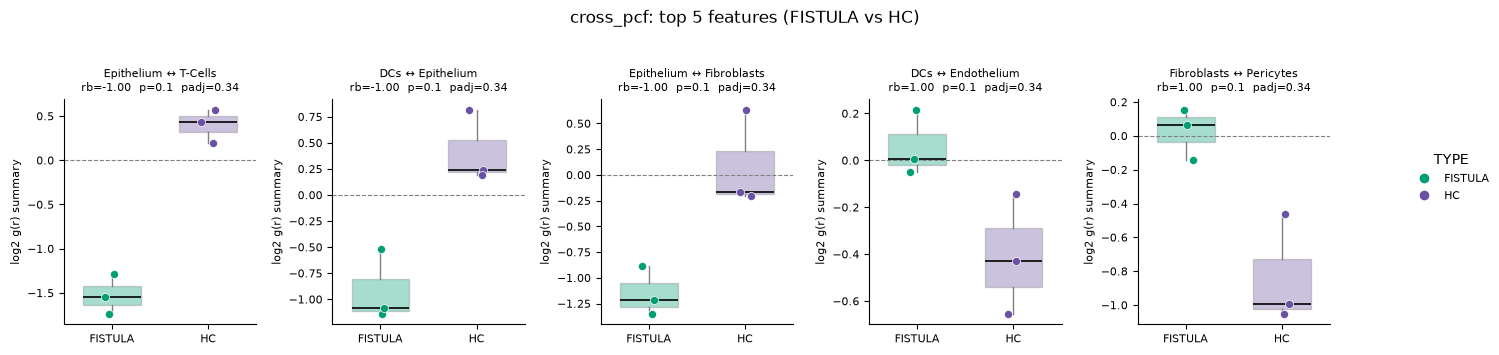

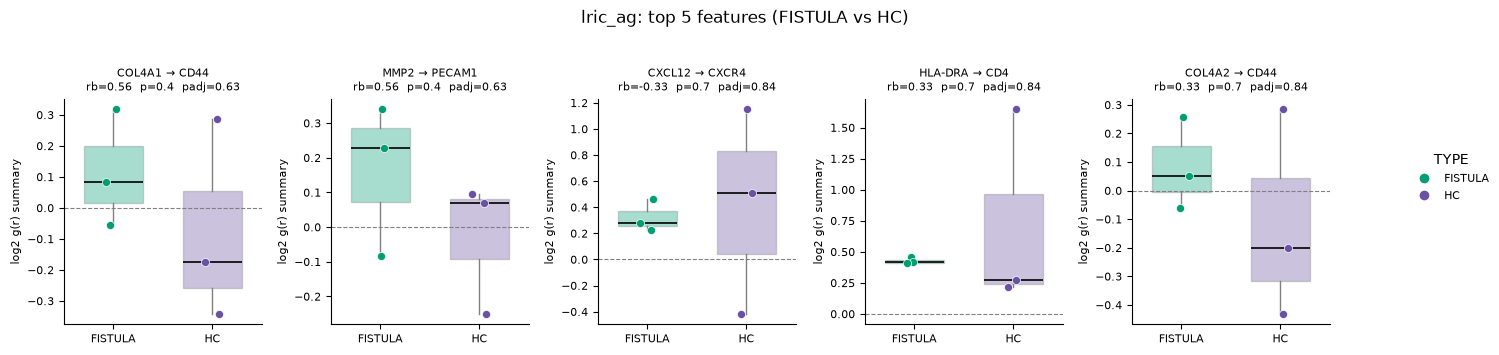

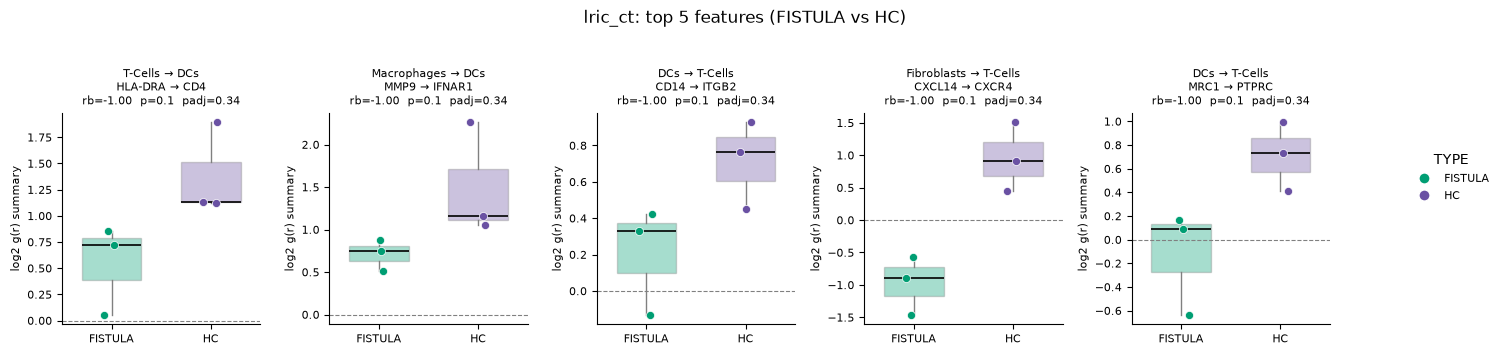

In [40]:
res = group_test(auc_df, min_n=3)                 # Mann–Whitney + rank-biserial + BH-FDR, per (modality, feature)

for mod in ("cross_pcf", "lric_ag", "lric_ct"):
    plot_group_boxplots(auc_df, res, mod, top_n=5) 

In [41]:
def _pair_data(adata, modality, fa, fb, max_dist=None, min_bins=3):
    ads = [adata] if hasattr(adata, "uns") else list(adata)
    x0, A, B = None, [], []

    def get(ad, f):
        for k, y in _iter_features(ad, modality):
            if k == f or (modality == "cross_pcf" and frozenset(k) == frozenset(f)):
                return _log2g(y)
        raise KeyError(f"{f!r} not found in {modality!r}")

    for ad in ads:
        r = np.asarray(ad.uns[modality]["radii"], float)
        if x0 is not None and not np.allclose(r, x0): raise ValueError("Radii differ between samples.")
        x0 = r; A.append(get(ad, fa)); B.append(get(ad, fb))

    x, A, B = x0 + HALF_ANNULUS, np.vstack(A), np.vstack(B)
    keep = np.isfinite(x) & np.isfinite(A).all(0) & np.isfinite(B).all(0)
    if max_dist is not None: keep &= x0 < max_dist
    if keep.sum() < min_bins: raise ValueError(f"Only {keep.sum()} shared finite bins.")
    return x[keep], A[:, keep], B[:, keep]


def divergence_log2_test(adata, modality, feature_a, feature_b, *,
                         max_dist=None, normalize=True, min_bins=3,
                         max_perm=2000, seed=0):
    """Area between two mean log2 g(r) curves; paired sign-flip p-value."""
    x, A, B = _pair_data(adata, modality, feature_a, feature_b, max_dist, min_bins)
    D = A - B; d = D.mean(0); span = x[-1] - x[0]
    scale = span if normalize and span > 0 else 1
    T = np.trapezoid(abs(d), x) / scale
    j, n = np.argmax(abs(d)), len(D)

    p, nperm = np.nan, 0
    if n > 1:
        exact = 2**n <= max_perm
        S = (np.array(list(itertools.product((-1, 1), repeat=n))) if exact else
             np.random.default_rng(seed).choice((-1, 1), (max_perm, n)))
        Tp = np.trapezoid(abs(S @ D / n), x, axis=1) / scale
        nperm = len(Tp); hits = (Tp >= T * (1 - 1e-12)).sum()
        p = hits / nperm if exact else (hits + 1) / (nperm + 1)

    return pd.Series({
        "modality": modality, "feature_a": feature_a, "feature_b": feature_b,
        "label_a": _feature_label(feature_a, modality).replace("\n", "  "),
        "label_b": _feature_label(feature_b, modality).replace("\n", "  "),
        "divergence": T, "r_star": x[j], "delta_star": d[j],
        "direction": "A > B" if d[j] > 0 else "B > A" if d[j] < 0 else "equal",
        "p": p, "n_samples": n, "n_perm": nperm,
        "max_dist": max_dist, "normalize": normalize, "min_bins": min_bins
    })


    """Group mean ± SD curves; grey band between the means = divergence, dotted line = r_star."""
    top = res.head(top_n); want = set(top.feature); gc, x = {}, None
    for ad in adata_list:
        grp = str(ad.obs[OBS["type"]].iloc[0])
        if grp not in (a, b): continue
        x = np.asarray(ad.uns[modality]["radii"], float) + HALF_ANNULUS
        keys, ys = zip(*[(k, _log2g(c)) for k, c in _iter_features(ad, modality)])
        Y = np.vstack(ys)
        if center: Y = Y - np.nanmedian(Y, axis=0, keepdims=True)   # same centering as compare_curves
        for k, y in zip(keys, Y):
            if k in want: gc.setdefault(k, {}).setdefault(grp, []).append(y)

    ncol = min(ncol, len(top)); nrow = int(np.ceil(len(top)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.4*nrow), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        m = {g: np.vstack(v) for g, v in gc[row.feature].items()}
        ax.fill_between(x, m[a].mean(0), m[b].mean(0), color="0.6", alpha=.35, lw=0)
        for g in (a, b):
            mu, sd = m[g].mean(0), m[g].std(0)
            ax.fill_between(x, mu-sd, mu+sd, color=GROUP_COLORS[g], alpha=.15, lw=0)
            ax.plot(x, mu, color=GROUP_COLORS[g], lw=2)
        ax.axvline(row.r_star, color="black", ls=":", lw=1)
        ax.axhline(0, color="grey", ls="--", lw=.8)
        ax.set_title(f"{_feature_label(row.feature, modality)}\ndiv={row['divergence']:.1f}  "
                     f"r*={row.r_star:.0f}µm  p={row.p:.2g}", fontsize=8)
        ax.set_xlabel("radius r (µm)", fontsize=8)
        ax.set_ylabel("centered log2 g(r)" if center else "log2 g(r)", fontsize=8)
        ax.tick_params(labelsize=8)
    for ax in axes.ravel()[len(top):]: ax.set_visible(False)
    h = [plt.Line2D([0],[0], color=GROUP_COLORS[g], lw=2, label=f"{g} (mean±SD)") for g in (a, b)]
    h += [plt.Rectangle((0,0),1,1, color="0.6", alpha=.35, label="divergence")]
    fig.legend(handles=h, loc="upper right", bbox_to_anchor=(1,1), frameon=False, fontsize=8)
    fig.suptitle(f"{modality}: top {len(top)} by divergence ({a} vs {b})", y=1.02)
    fig.tight_layout(rect=[0,0,.88,1]); plt.show()

In [42]:
def _bh(p):
    p = np.asarray(p, float); n = p.size; o = np.argsort(p)
    r = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    out = np.empty(n); out[o] = np.clip(r, 0, 1); return out

def divergence_scan(adata, modality, pairs, **kw):
    """Run divergence_log2_test over many (feature_a, feature_b) pairs (one adata or an
    adata_list) → one DataFrame, BH-FDR across the scanned pairs, sorted by divergence.
    **kw (max_dist, normalize, min_bins, max_perm, seed) pass straight through."""
    res = pd.DataFrame([divergence_log2_test(adata, modality, fa, fb, **kw) for fa, fb in pairs])
    ok = res["p"].notna().values
    res["padj"] = np.nan
    if ok.any(): res.loc[ok, "padj"] = _bh(res.loc[ok, "p"].values)
    return res.sort_values("divergence", ascending=False).reset_index(drop=True)

def _draw_pair(ax, x, A, B, row):
    ma, mb = A.mean(0), B.mean(0)
    ax.fill_between(x, ma, mb, color="0.6", alpha=.35, lw=0, label="divergence")
    for M, mu, col, lab in ((A, ma, C_TOP, row.label_a), (B, mb, C_BOT, row.label_b)):
        ax.fill_between(x, mu - M.std(0), mu + M.std(0), color=col, alpha=.15, lw=0)
        ax.plot(x, mu, color=col, lw=2, label=lab)
    ax.axvline(row.r_star, color="black", ls=":", lw=1); ax.axhline(0, color="grey", ls="--", lw=.8)
    pstr = f"  p={row.p:.2g}" if np.isfinite(row.p) else ""
    ax.set_title(f"div={row.divergence:.3g}   r*={row.r_star:.0f}µm{pstr}", fontsize=8)
    ax.legend(frameon=False, fontsize=6, loc="best")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)

def plot_divergence_grid(adata, res, *, top_n=6, ncol=3, figsize=None):
    """Faceted top-N pairs by divergence (same grammar as the single-pair plot): mean±SD
    curves for each feature, grey divergence band, dotted r_star. `res` from divergence_scan
    (carries max_dist/min_bins so the panels reproduce the tested window)."""
    top = res.head(top_n); n = len(top); ncol = min(ncol, n); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize or (4.3 * ncol, 3.6 * nrow), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        x, A, B = _pair_data(adata, row.modality, row.feature_a, row.feature_b, row.max_dist, row.min_bins)
        _draw_pair(ax, x, A, B, row)
        ax.set_xlabel("radius r (µm)", fontsize=8); ax.set_ylabel("log2 g(r)", fontsize=8); ax.tick_params(labelsize=8)
    for ax in axes.ravel()[n:]: ax.set_visible(False)
    fig.suptitle(f"{res.modality.iloc[0]}: top {n} by divergence", y=1.02)
    fig.tight_layout(); return fig

In [44]:
def _bh(p):
    p = np.asarray(p, float); n = p.size; o = np.argsort(p)
    r = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    out = np.empty(n); out[o] = np.clip(r, 0, 1); return out

def common_features(adata_list, modality):
    """Feature keys present in EVERY sample (cross_pcf keyed by unordered pair). Build `pairs`
    from these — a paired cross-sample test can only compare features measured everywhere."""
    ads = [adata_list] if hasattr(adata_list, "uns") else list(adata_list)
    norm = (lambda k: frozenset(k)) if modality == "cross_pcf" else (lambda k: k)
    common = set.intersection(*({norm(k) for k, _ in _iter_features(ad, modality)} for ad in ads))
    return [k for k, _ in _iter_features(ads[0], modality) if norm(k) in common]

def divergence_scan(adata, modality, pairs, **kw):
    """Run divergence_log2_test over many (feature_a, feature_b) pairs (one adata or an
    adata_list) → one DataFrame, BH-FDR across the scanned pairs, sorted by divergence. Pairs
    whose features are absent / NaN-masked in some sample are skipped. **kw (max_dist,
    normalize, min_bins, max_perm, seed) pass straight through."""
    rows = []
    for fa, fb in pairs:
        try: rows.append(divergence_log2_test(adata, modality, fa, fb, **kw))
        except (KeyError, ValueError): continue        # feature missing in a sample / too few shared bins
    res = pd.DataFrame(rows)
    if not len(res):
        raise ValueError("No pairs survived — features absent, NaN-masked, or radii differ across "
                         "samples. Build `pairs` from common_features(adata_list, modality).")
    ok = res["p"].notna().values
    res["padj"] = np.nan
    if ok.any(): res.loc[ok, "padj"] = _bh(res.loc[ok, "p"].values)
    return res.sort_values("divergence", ascending=False).reset_index(drop=True)

def _draw_pair(ax, x, A, B, row):
    ma, mb = A.mean(0), B.mean(0)
    ax.fill_between(x, ma, mb, color="0.6", alpha=.35, lw=0, label="divergence")
    for M, mu, col, lab in ((A, ma, C_TOP, row.label_a), (B, mb, C_BOT, row.label_b)):
        ax.fill_between(x, mu - M.std(0), mu + M.std(0), color=col, alpha=.15, lw=0)
        ax.plot(x, mu, color=col, lw=2, label=lab)
    ax.axvline(row.r_star, color="black", ls=":", lw=1); ax.axhline(0, color="grey", ls="--", lw=.8)
    pstr = f"  p={row.p:.2g}" if np.isfinite(row.p) else ""
    ax.set_title(f"div={row.divergence:.3g}   r*={row.r_star:.0f}µm{pstr}", fontsize=8)
    ax.legend(frameon=False, fontsize=6, loc="best")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)

def plot_divergence_grid(adata, res, *, top_n=6, ncol=3, figsize=None):
    """Faceted top-N pairs by divergence (same grammar as the single-pair plot): mean±SD
    curves for each feature, grey divergence band, dotted r_star. `res` from divergence_scan
    (carries max_dist/min_bins so the panels reproduce the tested window)."""
    top = res.head(top_n); n = len(top); ncol = min(ncol, n); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize or (4.3 * ncol, 3.6 * nrow), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        x, A, B = _pair_data(adata, row.modality, row.feature_a, row.feature_b, row.max_dist, row.min_bins)
        _draw_pair(ax, x, A, B, row)
        ax.set_xlabel("radius r (µm)", fontsize=8); ax.set_ylabel("log2 g(r)", fontsize=8); ax.tick_params(labelsize=8)
    for ax in axes.ravel()[n:]: ax.set_visible(False)
    fig.suptitle(f"{res.modality.iloc[0]}: top {n} by divergence", y=1.02)
    fig.tight_layout(); return fig

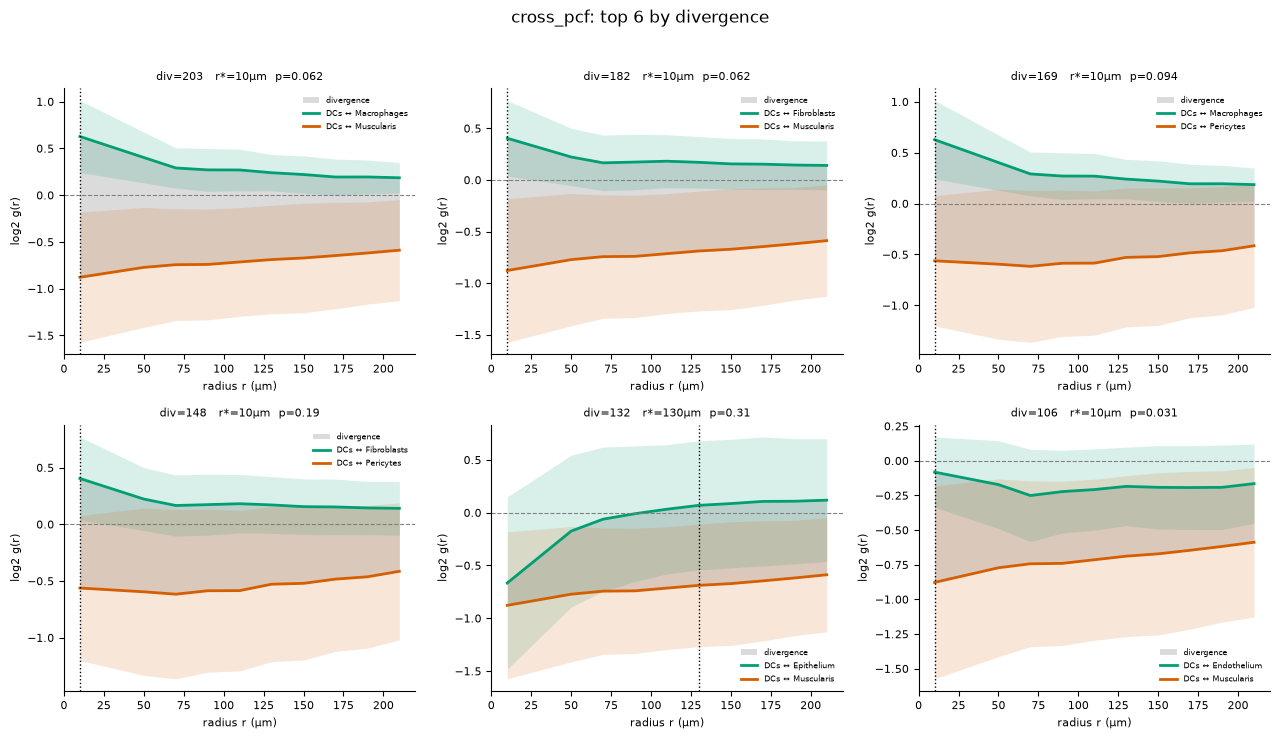

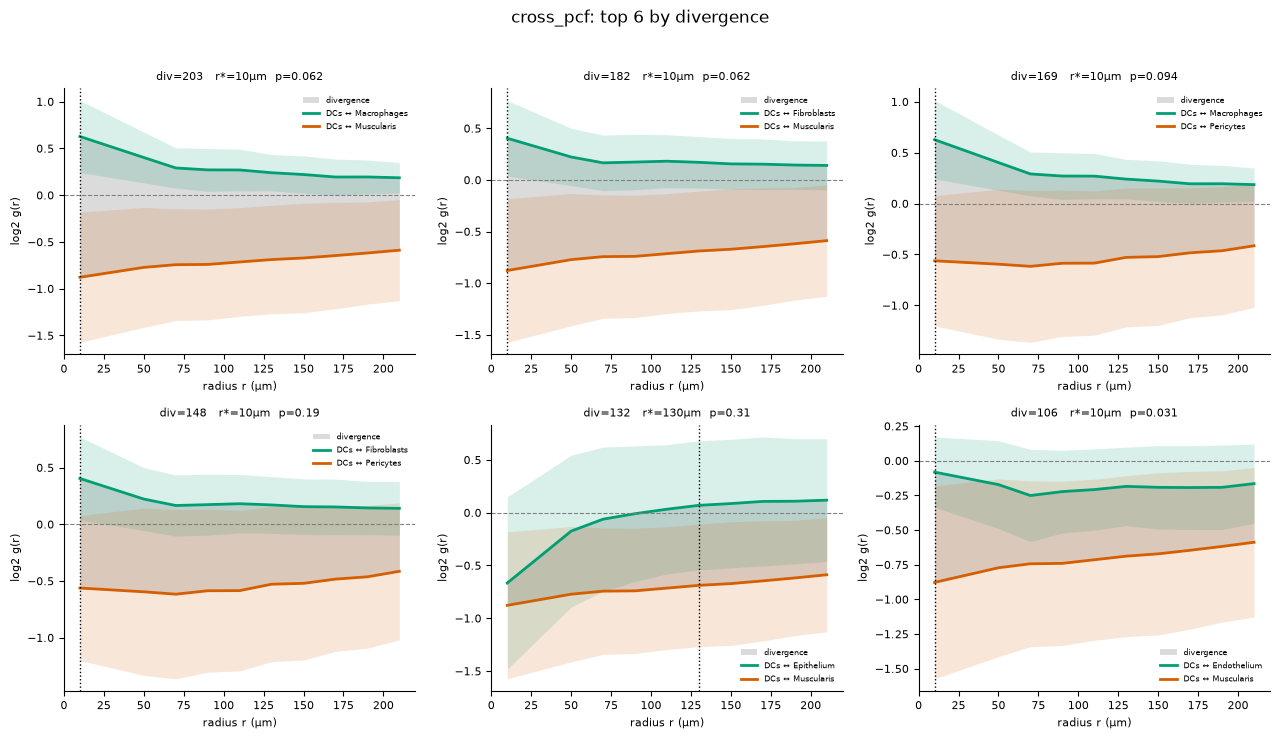

In [45]:
import itertools
feats = [k for k, _ in _iter_features(adata_list[0], "cross_pcf")]

# pick which pairs to compare:
pairs = list(itertools.combinations(feats[:8], 2))          # all pairs among a curated set
# ref = ("Epithelium","T-Cells"); pairs = [(ref,f) for f in feats if frozenset(f)!=frozenset(ref)]  # one vs rest

res = divergence_scan(adata_list, "cross_pcf", pairs, normalize=False)   # normalize=False = raw ∫ (your figure scale)
res.to_csv("divergence_scan.csv", index=False)
plot_divergence_grid(adata_list, res, top_n=6, ncol=3)

---

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>